# Brief Introduction to Pandas

- Provides a powerful `DataFrame` object.
- Makes it easy to deal with "Tabular" data.
- Very easy to read, process and visualize data.
- See http://pandas.pydata.org

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Fundamentals

- Why do we need this?
- Data is often **tabular**
  - Imagine the class marks in a course or during a program
  - Imagine a population with weight, height, age etc.

- Think of each student as a row
- Each column as an attribute
- So the columns are **aligned** using the row

- With `pandas`, data alignment is **central**

There are three fundamental building blocks in pandas:
1. `pd.Series`
2. `pd.DataFrame` and
3. `pd.Index`

We will look into the first two as they are the most important.

## Building block: `Series`

- "Labels" are collectively called the **index**
- `Series`: bundles together an index and values
- Index can be implicit or explicit


In [2]:
sn = pd.Series(np.random.normal(size=5))
sn

0    0.653552
1   -0.218601
2    0.076846
3   -0.774586
4    0.470085
dtype: float64

In [3]:
sn.values

array([ 0.6535524 , -0.21860148,  0.07684572, -0.77458563,  0.4700852 ])

In [4]:
sn.shape

(5,)

In [4]:
sn.index

RangeIndex(start=0, stop=5, step=1)


The values attribute is a numpy array

The index is an instance of `pd.Index` which is another fundamental building
block.

In [2]:
sa = pd.Series(np.random.normal(size=5), index=["a", "b", "c", "d", "e"])
sa

a   -0.424559
b    0.472706
c    0.268976
d   -0.706040
e    2.464989
dtype: float64

In [6]:
sn[0]

np.float64(0.5002212228508541)

In [7]:
# Note the warning!
sa[0]

C:\Users\SUSHANT\AppData\Local\Temp\ipykernel_37240\3794450938.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sa[0]


np.float64(0.959972305977546)

In [8]:
# This is the right way to access.
sa['a']

np.float64(0.959972305977546)

### `Series`: some points to note

- They behave like `numpy` arrays or dictionaries
- But carry the index
- All operations align on the label (i.e. index)
- The indices need not be contiguous or even be integers
- In a sense the `Series` is like a special dictionary keyed on index.
- Unaligned series will use the union of indices
- `NaN` is used to refer to missing values


In [9]:
# Can be initialized with a dictionary
a = pd.Series(dict(x=1, a=21, b=2))
a

x     1
a    21
b     2
dtype: int64

In [10]:
# Or with explicit values and indices
a = pd.Series(np.arange(5), index=range(100, 110, 2))
a

100    0
102    1
104    2
106    3
108    4
dtype: int64

In [ ]:
a[102]

In [11]:
a = pd.Series(np.ones(5), index=["a", "b", "c", "d", "e"])
b = pd.Series(np.arange(5), index=["e", "d", "c", "b", "a"])
a + b

a    5.0
b    4.0
c    3.0
d    2.0
e    1.0
dtype: float64

In [ ]:
a.dtype

In [12]:
a = pd.Series(np.ones(5), index=["a", "b", "c", "d", "e"])
b = pd.Series(np.arange(4), index=["e", "d", "c", "b"])
a + b

a    NaN
b    4.0
c    3.0
d    2.0
e    1.0
dtype: float64

### Aside

- `NaN` is a number!
- Beware of them
- Used to denote missing values in pandas.

In [ ]:
float('nan'), float('NaN')

In [ ]:
type(float('nan'))

In [ ]:
np.nan

In [13]:
x = np.arange(5, dtype=float)
np.sum(x)

np.float64(10.0)

In [14]:
x[0] = np.nan
np.mean(x)

np.float64(nan)

- Use `np.nan*` functions
- `np.isnan` is also handy


In [15]:
np.nansum(x)

np.float64(10.0)

## `DataFrame` basics

- A table of data: a spreadsheet
- Same index for all columns
- Different data types per column
- Think of it as a 2D numpy array with flexible row and column names.

We can construct these using Series objects.

In [17]:
state_pop = {'Maharashtra': 112374333, 'UP': 199812341, 'Bihar': 104099452,
             'West Bengal': 91276115, 'MP': 72626809}
pop = pd.Series(state_pop)
pop

Maharashtra    112374333
UP             199812341
Bihar          104099452
West Bengal     91276115
MP              72626809
dtype: int64

In [18]:
state_area = {'MP': 308252,  'UP': 240928, 'Maharashtra': 307713, 'Bihar': 94163,
              'West Bengal': 88752}
area = pd.Series(state_area)

In [19]:
states = pd.DataFrame({'population': pop, 'area': area})
states

,population,area
Bihar,104099452,94163
MP,72626809,308252
Maharashtra,112374333,307713
UP,199812341,240928
West Bengal,91276115,88752


In [20]:
states.index

Index(['Bihar', 'MP', 'Maharashtra', 'UP', 'West Bengal'], dtype='object')

In [21]:
states.columns

Index(['population', 'area'], dtype='object')

In [22]:
states['area']

Bihar           94163
MP             308252
Maharashtra    307713
UP             240928
West Bengal     88752
Name: area, dtype: int64

In [23]:
states['population']

Bihar          104099452
MP              72626809
Maharashtra    112374333
UP             199812341
West Bengal     91276115
Name: population, dtype: int64

In [24]:
states.area

Bihar           94163
MP             308252
Maharashtra    307713
UP             240928
West Bengal     88752
Name: area, dtype: int64


Can also create a data frame by supplying lists or numpy arrays

In [3]:
d = pd.DataFrame(dict(x=[1, 2, 3], y=['hello', 'class', '2025']))

In [4]:
d

,x,y
0,1,hello
1,2,class
2,3,2025


In [5]:
# Note that the index is implicit which may not be ideal
d.index

RangeIndex(start=0, stop=3, step=1)

In [28]:
d.describe()

,x
count,3.0
mean,2.0
std,1.0
min,1.0
25%,1.5
50%,2.0
75%,2.5
max,3.0


In [ ]:
d.dtypes

Can create the array with a two-dimensional numpy array

In [ ]:
pd.DataFrame(np.random.rand(3, 2), columns=['foo', 'bar'], index=['a', 'b', 'c'])

,foo,bar
a,0.935559,0.038454
b,0.178835,0.679140
c,0.681178,0.168042


## The `pd.Index` object

Can be constructed explicitly

In [7]:
ind = pd.Index([2, 4, 6, 8, 10])
ind

Index([2, 4, 6, 8, 10], dtype='int64')

In [8]:
ind1 = pd.Index([2, 3, 5, 7, 11])


- The index is immutable
- Supports basic set-like operations
  - Union, `|`
  - Intersection, `&`
  - Symmetric difference, `^`

In [9]:
ind.union(ind1)

Index([2, 3, 4, 5, 6, 7, 8, 10, 11], dtype='int64')

In [10]:
ind.intersection(ind1)

Index([2], dtype='int64')

### A toy example.

- This is a boring dataset but easy to create and demonstrate the basic
  features.

In [7]:
x = np.linspace(0, 2*np.pi, 100)
sin = np.sin(x)
cos = np.cos(x)

In [6]:
df = pd.DataFrame(dict(x=x, sin=sin))
df.set_index(x)
print(df)

           x           sin
0   0.000000  0.000000e+00
1   0.063467  6.342392e-02
2   0.126933  1.265925e-01
3   0.190400  1.892512e-01
4   0.253866  2.511480e-01
..       ...           ...
95  6.029319 -2.511480e-01
96  6.092786 -1.892512e-01
97  6.156252 -1.265925e-01
98  6.219719 -6.342392e-02
99  6.283185 -2.449294e-16

[100 rows x 2 columns]


In [8]:
df = pd.DataFrame({'x': x, 'sin': sin, 'cos': cos, 'x-data':x})
# OR
#df = pd.DataFrame(dict(x=x, sin=sin, cos=cos))

In [8]:
df.head(11)  # or df.tail()

,x,sin,cos,x-data
0,0.000000,0.000000,1.000000,0.000000
1,0.063467,0.063424,0.997987,0.063467
2,0.126933,0.126592,0.991955,0.126933
3,0.190400,0.189251,0.981929,0.190400
4,0.253866,0.251148,0.967949,0.253866
5,0.317333,0.312033,0.950071,0.317333
6,0.380799,0.371662,0.928368,0.380799
7,0.444266,0.429795,0.902927,0.444266
8,0.507732,0.486197,0.873849,0.507732
9,0.571199,0.540641,0.841254,0.571199


In [ ]:
df.tail()

In [40]:
df.describe()

,x,sin,cos,x-data
count,100.000000,1.000000e+02,100.000000,100.000000
mean,3.141593,-1.577197e-17,0.010000,3.141593
std,1.841258,7.071068e-01,0.714143,1.841258
min,0.000000,-9.998741e-01,-0.999497,0.000000
25%,1.570796,-6.957328e-01,-0.701475,1.570796
50%,3.141593,-1.224647e-16,0.015858,3.141593
75%,4.712389,6.957328e-01,0.723734,4.712389
max,6.283185,9.998741e-01,1.000000,6.283185


In [ ]:
df.info()

In [ ]:
df['x-data']

In [41]:
df.x[::10]

0     0.000000
10    0.634665
20    1.269330
30    1.903996
40    2.538661
50    3.173326
60    3.807991
70    4.442656
80    5.077321
90    5.711987
Name: x, dtype: float64

In [42]:
# df.x-data[:5] will not work!!
df['x-data'][:5]

0    0.000000
1    0.063467
2    0.126933
3    0.190400
4    0.253866
Name: x-data, dtype: float64

In [ ]:
df['x'][:5]

In [43]:
df.x[:10]

0    0.000000
1    0.063467
2    0.126933
3    0.190400
4    0.253866
5    0.317333
6    0.380799
7    0.444266
8    0.507732
9    0.571199
Name: x, dtype: float64

In [44]:
df.columns

Index(['x', 'sin', 'cos', 'x-data'], dtype='object')

In [ ]:
# Very useful when reading a file to ensure that the types are correctly
# parsed.
df.dtypes

In [45]:
len(df)

100

In [ ]:
df.index

In [ ]:
df1 = df.copy()
df1.head()

Indexing
=========

Can do what we did above but also using:

- Select column: `df[col]`
- Slice rows: `df[3:13]`
- Select row by label: `df.loc[label_index]`
- Select row by numerical index: `df.iloc[integer]`
- Select rows by boolean vector: `df[bool_vec]`
- Select rows/colunns: `df[bool_vec, [label1, label2]]`
- `iloc`, `loc` are useful since using `[]` is confusing.

Shall explore this below.


In [ ]:
df['x']  # Access a column

In [46]:
df.loc[10]

x         0.634665
sin       0.592908
cos       0.805270
x-data    0.634665
Name: 10, dtype: float64

In [49]:
df.loc[:10]

,x,sin,cos,x-data
0,0.000000,0.000000,1.000000,0.000000
1,0.063467,0.063424,0.997987,0.063467
2,0.126933,0.126592,0.991955,0.126933
3,0.190400,0.189251,0.981929,0.190400
4,0.253866,0.251148,0.967949,0.253866
5,0.317333,0.312033,0.950071,0.317333
6,0.380799,0.371662,0.928368,0.380799
7,0.444266,0.429795,0.902927,0.444266
8,0.507732,0.486197,0.873849,0.507732
9,0.571199,0.540641,0.841254,0.571199


In [50]:
df.loc[:10, 'x']

0     0.000000
1     0.063467
2     0.126933
3     0.190400
4     0.253866
5     0.317333
6     0.380799
7     0.444266
8     0.507732
9     0.571199
10    0.634665
Name: x, dtype: float64

In [51]:
df.loc[:10, ['sin', 'cos']]

,sin,cos
0,0.000000,1.000000
1,0.063424,0.997987
2,0.126592,0.991955
3,0.189251,0.981929
4,0.251148,0.967949
5,0.312033,0.950071
6,0.371662,0.928368
7,0.429795,0.902927
8,0.486197,0.873849
9,0.540641,0.841254


In [52]:
# This is not different in this case as the indices are integers
# Better example below.
df.iloc[:10]

,x,sin,cos,x-data
0,0.000000,0.000000,1.000000,0.000000
1,0.063467,0.063424,0.997987,0.063467
2,0.126933,0.126592,0.991955,0.126933
3,0.190400,0.189251,0.981929,0.190400
4,0.253866,0.251148,0.967949,0.253866
5,0.317333,0.312033,0.950071,0.317333
6,0.380799,0.371662,0.928368,0.380799
7,0.444266,0.429795,0.902927,0.444266
8,0.507732,0.486197,0.873849,0.507732
9,0.571199,0.540641,0.841254,0.571199


### Examples with non-integer index


In [54]:
d = pd.DataFrame(dict(x=[1, 2, 3], y=['hello', 'class', '2021']), index=list('abc'))
d

,x,y
a,1,hello
b,2,class
c,3,2021


In [55]:
d.loc['a']

x        1
y    hello
Name: a, dtype: object

In [56]:
# Note that this includes the last slice label!
d.loc['a':'b']

,x,y
a,1,hello
b,2,class


In [57]:
d.iloc[0]

x        1
y    hello
Name: a, dtype: object

In [58]:
d[1:3]

,x,y
b,2,class
c,3,2021



Back to our original DataFrame, `df`
- Give me a dataframe, where all cosine values are >0.

In [9]:
df_filtered_rows = df[df['cos'] > 0.8]
df_filtered_rows

,x,sin,cos,x-data
0,0.000000,0.000000e+00,1.000000,0.000000
1,0.063467,6.342392e-02,0.997987,0.063467
2,0.126933,1.265925e-01,0.991955,0.126933
3,0.190400,1.892512e-01,0.981929,0.190400
4,0.253866,2.511480e-01,0.967949,0.253866
5,0.317333,3.120334e-01,0.950071,0.317333
6,0.380799,3.716625e-01,0.928368,0.380799
7,0.444266,4.297949e-01,0.902927,0.444266
8,0.507732,4.861967e-01,0.873849,0.507732
9,0.571199,5.406408e-01,0.841254,0.571199


In [77]:
# Recall masked indexing
y = np.linspace(10, 11, 11)
y

array([10. , 10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10.7, 10.8, 10.9, 11. ])

In [78]:
y > 10.5

array([False, False, False, False, False, False,  True,  True,  True,
        True,  True])

In [79]:
cond = y > 10.5
y[cond]

array([10.6, 10.7, 10.8, 10.9, 11. ])

- Same thing works with pandas

In [82]:
condition = df.cos > 0.8
print(len(condition))
print(condition.sum())

100
22


In [83]:
df_positive_cos = df[condition]
df_positive_cos.describe()

,x,sin,cos,x-data
count,22.000000,2.200000e+01,22.000000,22.000000
mean,3.141593,2.419213e-17,0.931051,3.141593
std,2.898012,3.676671e-01,0.065618,2.898012
min,0.000000,-5.929079e-01,0.805270,0.000000
25%,0.333199,-2.968121e-01,0.881119,0.333199
50%,3.141593,-1.224647e-16,0.950071,3.141593
75%,5.949986,2.968121e-01,0.989448,5.949986
max,6.283185,5.929079e-01,1.000000,6.283185


In [ ]:
# Combining conditionals
cond1 = df.sin > 0.0
df_all_positive = df[condition & cond1]
df_all_positive.describe()

In [ ]:
# Always, always use brackets when combining conditionals with bitwise
# operations.
df_all_positive = df[(df.cos > 0.0) & (df.sin > 0)]
df_all_positive.describe()

In [ ]:
# Use ~ for inverting the boolean as a Not
c = np.array([True, False, True, False])
c1 = np.array([False, True, False, False])
~(c | c1)

In [ ]:
cond1 = df_positive_cos.sin > 0.0
df_all_positive = df_positive_cos[cond1]
df_all_positive.describe()

In [84]:
# This adds a new column sincos
df['sincos'] = df.sin*df.cos
# Do not use df.sincos = ...
len(df.sincos)

100

In [85]:
df.describe()

,x,sin,cos,x-data,sincos
count,100.000000,1.000000e+02,100.000000,100.000000,1.000000e+02
mean,3.141593,-1.577197e-17,0.010000,3.141593,-1.755404e-18
std,1.841258,7.071068e-01,0.714143,1.841258,3.535534e-01
min,0.000000,-9.998741e-01,-0.999497,0.000000,-4.999371e-01
25%,1.570796,-6.957328e-01,-0.701475,1.570796,-3.478664e-01
50%,3.141593,-1.224647e-16,0.015858,3.141593,-1.224647e-16
75%,4.712389,6.957328e-01,0.723734,4.712389,3.478664e-01
max,6.283185,9.998741e-01,1.000000,6.283185,4.999371e-01


In [87]:
for i in df.cos:
    print(i)

1.0
0.9979866764718844
0.9919548128307953
0.9819286972627067
0.9679487013963562
0.9500711177409454
0.9283679330160726
0.9029265382866212
0.8738493770697849
0.8412535328311812
0.8052702575310586
0.766044443118978
0.7237340381050702
0.6785094115571322
0.6305526670845225
0.5800569095711982
0.5272254676105024
0.4722710747726827
0.41541501300188644
0.3568862215918719
0.2969203753282749
0.23575893550942728
0.17364817766693041
0.1108381999010111
0.04758191582374218
-0.01586596383480803
-0.07924995685678854
-0.14231483827328523
-0.20480666806519074
-0.26647381369003503
-0.32706796331742166
-0.3863451256931287
-0.4440666126057741
-0.5000000000000002
-0.5539200638661103
-0.6056096871376668
-0.654860733945285
-0.7014748877063214
-0.7452644496757547
-0.7860530947427875
-0.8236765814298327
-0.8579834132349771
-0.8888354486549234
-0.9161084574320696
-0.9396926207859083
-0.9594929736144974
-0.975429786885407
-0.9874388886763943
-0.9954719225730846
-0.9994965423831851
-0.9994965423831851
-0.9954719225

In [86]:
if 'x-data' in df:
    del df['x-data']
df.head()

,x,sin,cos,sincos
0,0.000000,0.000000,1.000000,0.000000
1,0.063467,0.063424,0.997987,0.063296
2,0.126933,0.126592,0.991955,0.125574
3,0.190400,0.189251,0.981929,0.185831
4,0.253866,0.251148,0.967949,0.243098


### Operations and index alignment

- NumPy ufuncs can be applied
- All binary operations align on the index

In [10]:
d = pd.DataFrame(np.random.randint(0, 10, size=(3, 4)),
                 columns=['A', 'B', 'C', 'D'])
d

,A,B,C,D
0,7,0,4,1
1,3,2,0,2
2,4,1,6,8


In [89]:
np.sin(d)

,A,B,C,D
0,0.841471,0.412118,0.000000,-0.958924
1,0.141120,0.141120,0.656987,-0.958924
2,0.656987,-0.958924,0.656987,-0.756802


In [90]:
a = pd.DataFrame(np.random.randint(0, 20, (2, 2)),
                 columns=list('AB'))
a

b = pd.DataFrame(np.random.randint(0, 10, (3, 3)),
                 columns=list('BAC'))
b

,B,A,C
0,7,4,7
1,4,7,0
2,8,6,9


In [91]:
a + b

,A,B,C
0,7.0,10.0,NaN
1,26.0,9.0,NaN
2,NaN,NaN,NaN


In [92]:
a.add(b, fill_value=0.0)
a

,A,B
0,3,3
1,19,5


There are many other methods, `sub, mul, floordiv, div, pow`, etc.

### Missing values
- Nan used to deal with missing values
- None also used to deal with missing values in data of type `object`

In [93]:
s = pd.Series([1, np.nan, 'hello', None])
s

0        1
1      NaN
2    hello
3     None
dtype: object

In [94]:
s.isnull()

0    False
1     True
2    False
3     True
dtype: bool

In [95]:
s.notnull()

0     True
1    False
2     True
3    False
dtype: bool

In [96]:
s.dropna()

0        1
2    hello
dtype: object

In [97]:
# See the various arguments for each of these methods
s.fillna(0)

0        1
1        0
2    hello
3        0
dtype: object

### Assignment of values

When assigning values, do it directly using `.loc`

In [14]:
# Recall this
d

,A,B,C,D
0,1,8,6,2
1,6,8,7,7
2,7,4,0,4


In [15]:
# Note the warning!
d[d.A > 5]['A'] = 25
d

C:\Users\SUSHANT\AppData\Local\Temp\ipykernel_14620\2088146002.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d[d.A > 5]['A'] = 25


,A,B,C,D
0,1,8,6,2
1,6,8,7,7
2,7,4,0,4


In [15]:
# Instead do this:
d.loc[d.A > 5, 'A'] = 2527
d

,A,B,C,D
0,2527,25,25,25
1,3,2,0,2
2,4,1,6,8


- Always beware of this SettingWithCopyWarning warnings
- Avoid ever setting values on slices/subsets without due care.

### String processing

- For any string type, use the `str` attributes and its methods.
- This applies to `Series`, `Index` and `DataFrame` objects!

In [10]:
# From the pandas documentation.
s = pd.Series(
    ["A", "B", "C", "Aaba", "Baca", np.nan, "CABA", "dog", "cat"], dtype="string"
)

In [11]:
s.str.lower()

0       a
1       b
2       c
3    aaba
4    baca
5    <NA>
6    caba
7     dog
8     cat
dtype: string

In [12]:
s.str.upper()

0       A
1       B
2       C
3    AABA
4    BACA
5    <NA>
6    CABA
7     DOG
8     CAT
dtype: string

In [13]:
s.str.upper().str.replace('C', 'XX')

0        A
1        B
2       XX
3     AABA
4    BAXXA
5     <NA>
6    XXABA
7      DOG
8     XXAT
dtype: string

Plotting
=========

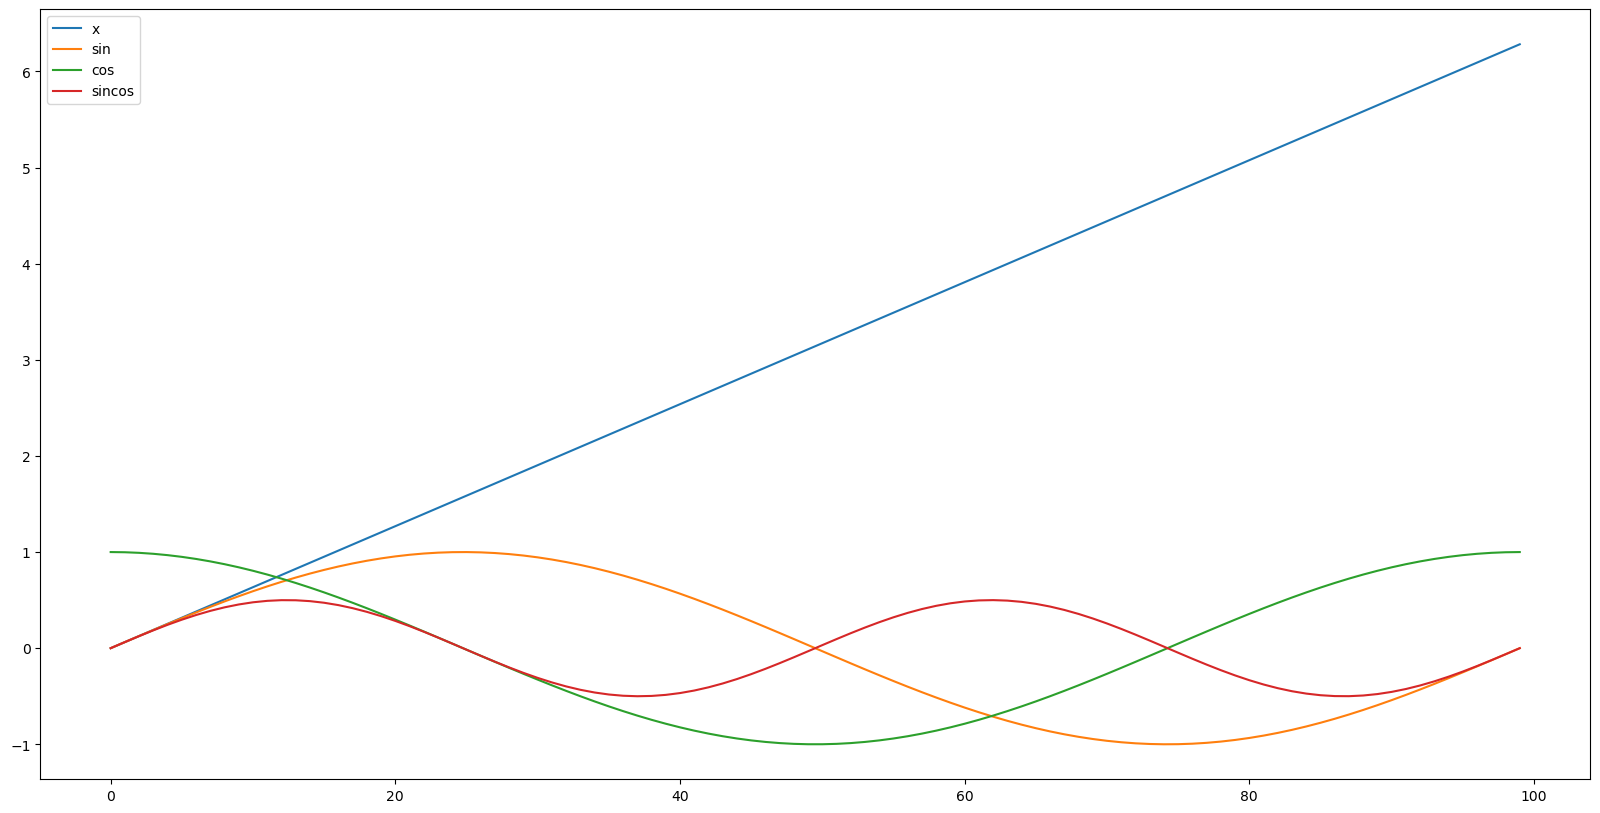

In [110]:
df.plot(figsize=(20, 10));
# or
#df.plot.line()

Notice that everything is plotted w.r.t. the index!
Let us fix this!

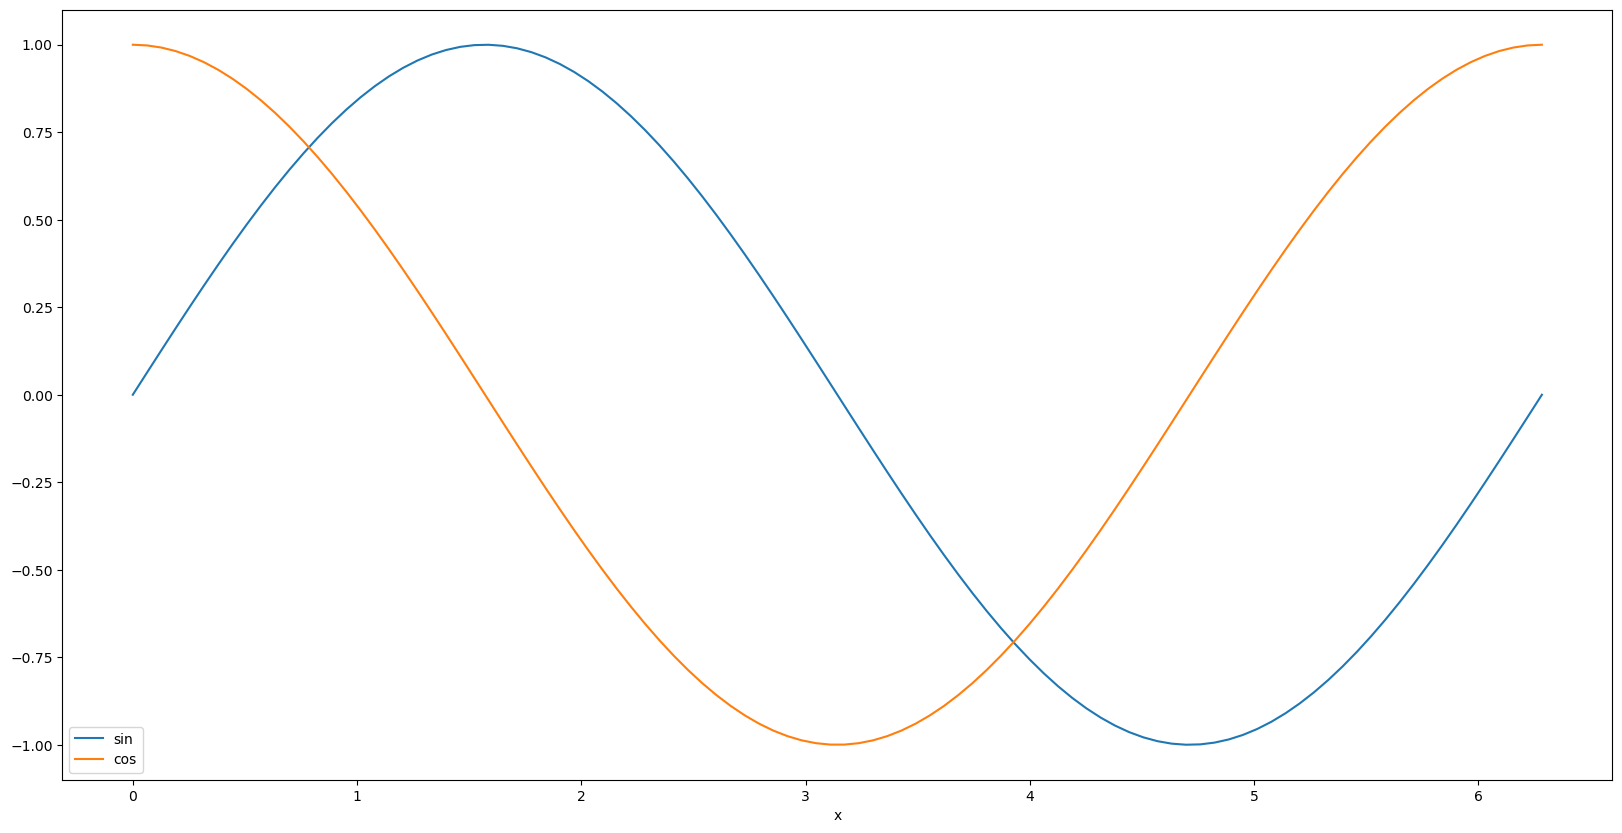

In [111]:
df.plot.line(x='x', y=['sin', 'cos'], figsize=(20, 10));

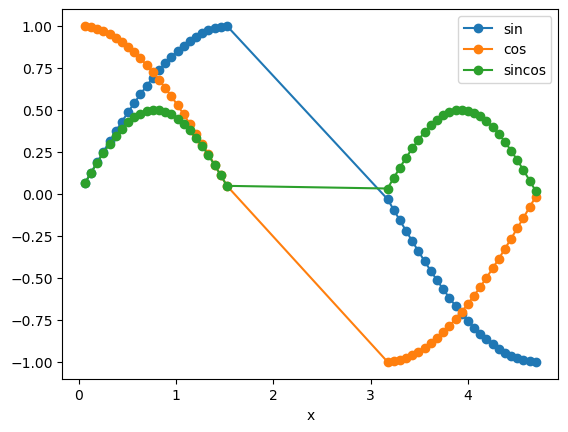

In [112]:
# See what this does
df[(df.sin > 0.0) ^ (df.cos < 0.0)].plot.line(x='x', marker='o');

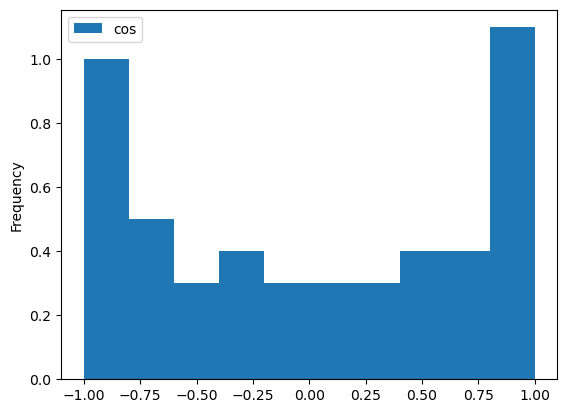

In [113]:
df.plot.hist(y='cos', density=True);
# or
#df.plot(y='cos', kind='hist');

Input and output CSV and other file formats
--------------------------------------------

- `pd.read_csv()`
- `df.to_csv()`
- Can read/save to clip board.
- Directly read from URLs.

In [114]:
df.to_csv('sincos.csv', index=False)

In [115]:
df1 = pd.read_csv('sincos.csv')
df1.head()

,x,sin,cos,sincos
0,0.000000,0.000000,1.000000,0.000000
1,0.063467,0.063424,0.997987,0.063296
2,0.126933,0.126592,0.991955,0.125574
3,0.190400,0.189251,0.981929,0.185831
4,0.253866,0.251148,0.967949,0.243098


### Conversion to LaTeX and HTML

In [116]:
print(df[:5].to_latex())

\begin{tabular}{lrrrr}
\toprule
 & x & sin & cos & sincos \\
\midrule
0 & 0.000000 & 0.000000 & 1.000000 & 0.000000 \\
1 & 0.063467 & 0.063424 & 0.997987 & 0.063296 \\
2 & 0.126933 & 0.126592 & 0.991955 & 0.125574 \\
3 & 0.190400 & 0.189251 & 0.981929 & 0.185831 \\
4 & 0.253866 & 0.251148 & 0.967949 & 0.243098 \\
\bottomrule
\end{tabular}



In [ ]:
print(df[:5].to_latex(index=False))

In [ ]:
print(df[:5].to_html())

In [117]:
from IPython.display import HTML
HTML(df[:5].to_html())

,x,sin,cos,sincos
0,0.000000,0.000000,1.000000,0.000000
1,0.063467,0.063424,0.997987,0.063296
2,0.126933,0.126592,0.991955,0.125574
3,0.190400,0.189251,0.981929,0.185831
4,0.253866,0.251148,0.967949,0.243098


Selecting from the clipboard
=============================

- Let us select data from our previous sincos data frame.
- Will use this for more interesting stuff.

Select some data and then do this:


In [119]:
df2 = pd.read_clipboard(sep=',')
df2

,GroupingAscending,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,4s,6s,Unnamed: 15
0,v Australia,1991-2012,71,70,1,3077,175,44.59,3632,84.71,9,15,2,330,35,view innings
1,v Bangladesh,1990-2012,12,11,1,496,114,49.60,583,85.07,1,2,0,67,5,view innings
2,v Bermuda,2007-2007,1,1,1,57,57*,-,29,196.55,0,1,0,2,4,view innings
3,v England,1990-2011,37,37,4,1455,120,44.09,1631,89.20,2,10,0,173,17,view innings
4,v Ireland,2007-2011,2,2,0,42,38,21.00,59,71.18,0,0,0,5,0,view innings
5,v Kenya,1996-2003,10,9,3,647,146,107.83,667,97.00,4,1,0,73,5,view innings
6,v Namibia,2003-2003,1,1,0,152,152,152.00,151,100.66,1,0,0,18,0,view innings
7,v Netherlands,2003-2011,2,2,0,79,52,39.50,94,84.04,0,1,0,13,0,view innings
8,v New Zealand,1990-2009,42,41,3,1750,186*,46.05,1835,95.36,5,8,4,206,26,view innings
9,v Pakistan,1989-2012,69,67,4,2526,141,40.09,2887,87.49,5,16,5,294,29,view innings


In [ ]:
url = 'https://drive.google.com/uc?id=1VgrBnWERE9YLslOoCLu8ZFLRbUu4jOED'
df = pd.read_csv(url, sep=';')

In [120]:
df.head()

,x,sin,cos,sincos
0,0.000000,0.000000,1.000000,0.000000
1,0.063467,0.063424,0.997987,0.063296
2,0.126933,0.126592,0.991955,0.125574
3,0.190400,0.189251,0.981929,0.185831
4,0.253866,0.251148,0.967949,0.243098


In [ ]:
df.describe()

## Example: Getting Kohli's batting scores

- Obtaining the Batting score data for ODIs.
- We walk through how we get the data for V. Kohli
- First visit here: https://stats.espncricinfo.com/ci/engine/player/253802.html?class=2;template=results;type=batting;view=innings

In [17]:
df = pd.read_clipboard()
r = df.Runs.str.replace('*', '')
r1 = r[~r.str.contains('DNB')]
np.savetxt('../tmp/kohli.txt', r1.to_numpy(dtype=np.int32), fmt='%d')

## Example: Getting all Kohli's ODI batting data

- Obtaining all available data
- First visit here: https://stats.espncricinfo.com/ci/engine/player/253802.html?class=2;template=results;type=batting;view=innings

In [18]:
data = pd.read_clipboard()

In [19]:
# Strip any leading/trailing whitespace from the column headers.
data.columns

Index(['Runs', 'Mins', 'BF', '4s', '6s', 'SR', 'Pos', 'Dismissal', 'Inns',
       'Unnamed: 9', 'Opposition', 'Ground', 'Start DateAscending',
       'Unnamed: 13'],
      dtype='object')

In [20]:
data.columns = data.columns.str.strip()

In [21]:
# Remove columns that are completely empty or were artifacts of the import
# process.
unnamed_cols = [col for col in data.columns if "Unnamed" in col]

# The above is a list comprehension. Equivalent to the following.
unnamed_cols = []
for col in data.columns:
    if "Unnamed" in col:
        unnamed_cols.append(col)

# Now drop the columns
data = data.drop(columns=unnamed_cols)

In [22]:
# The 'Runs' column contains non-numeric characters like '*' for not-out
# innings. This section removes them and converts the column to a numeric type.
data["Runs"] = (
    data["Runs"].astype(str)
    .str.replace("*", "", regex=False)
    .replace("DNB", np.nan)  # Replace 'Did Not Bat' with NaN
)
data["Runs"] = pd.to_numeric(data["Runs"], errors="coerce")

In [ ]:
# Convert the 'Start DateAscending' column to datetime objects.
# Then, create a 'Year' column and drop the original date column.
data["Date"] = pd.to_datetime(data["Start DateAscending"], errors="coerce")
data["Year"] = data["Date"].dt.year
data = data.drop(columns=["Start DateAscending"])

# Remove the "v " prefix from the 'Opposition' column for consistency.
data["Opposition"] = data["Opposition"].str.replace("v ", "", regex=False)

KeyError: 'Start DateAscending'

In [27]:
# Clean up text columns and create a binary 'NotOut' column.
data["Dismissal"] = (
    data["Dismissal"]
    .fillna("DNB")
    .astype(str)
    .str.strip()
    .fillna("DNB")
)
data["Ground"] = data["Ground"].str.strip()
data["Opposition"] = data["Opposition"].str.strip()
data["NotOut"] = data["Dismissal"].eq("not out").astype(int)

# Convert several other columns to numeric, coercing errors to NaN.
cols_to_numeric = ["BF", "4s", "6s", "Pos", "Inns", "SR"]
for col in cols_to_numeric:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Arrange the DataFrame columns in a more logical order.
final_column_order = [
    "Date", "Year", "Ground", "Opposition", "Inns", "Pos",
    "Runs", "BF", "4s", "6s", "SR", "Dismissal", "NotOut"
]
data = data[final_column_order]
data.info()

# Export the final, cleaned DataFrame to a new CSV file.
output_filename = "../tmp/sachin_cleaned_batting.csv"
data.to_csv(output_filename, index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        463 non-null    datetime64[ns]
 1   Year        463 non-null    int32         
 2   Ground      463 non-null    object        
 3   Opposition  463 non-null    object        
 4   Inns        457 non-null    float64       
 5   Pos         452 non-null    float64       
 6   Runs        452 non-null    float64       
 7   BF          452 non-null    float64       
 8   4s          452 non-null    float64       
 9   6s          452 non-null    float64       
 10  SR          452 non-null    float64       
 11  Dismissal   463 non-null    object        
 12  NotOut      463 non-null    int64         
dtypes: datetime64[ns](1), float64(7), int32(1), int64(1), object(3)
memory usage: 45.3+ KB


C:\Users\SUSHANT\AppData\Local\Temp\ipykernel_14620\3562106.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Dismissal"] = (
C:\Users\SUSHANT\AppData\Local\Temp\ipykernel_14620\3562106.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Ground"] = data["Ground"].str.strip()
C:\Users\SUSHANT\AppData\Local\Temp\ipykernel_14620\3562106.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th

### Some useful methods


In [28]:
(data.Runs > 100).value_counts()

Runs
False    420
True      43
Name: count, dtype: int64

In [48]:
data[(data.Opposition.str.lower().eq('australia'))]

,Date,Year,Ground,Opposition,Inns,Pos,Runs,BF,4s,6s,SR,Dismissal,NotOut
22,1991-12-08,1991,W.A.C.A,Australia,1.0,4.0,36.0,65.0,3.0,0.0,55.38,caught,0
23,1991-12-10,1991,Hobart,Australia,1.0,4.0,57.0,107.0,3.0,0.0,53.27,caught,0
25,1991-12-15,1991,Adelaide,Australia,1.0,4.0,21.0,35.0,3.0,0.0,60.00,caught,0
27,1992-01-14,1992,Sydney,Australia,1.0,5.0,31.0,44.0,1.0,0.0,70.45,run out,0
29,1992-01-18,1992,Melbourne,Australia,2.0,4.0,4.0,10.0,0.0,0.0,40.00,caught,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,2009-11-08,2009,Guwahati,Australia,1.0,2.0,10.0,17.0,2.0,0.0,58.82,caught,0
450,2011-03-24,2011,Ahmedabad,Australia,2.0,2.0,53.0,68.0,7.0,0.0,77.94,caught,0
453,2012-02-05,2012,Melbourne,Australia,2.0,2.0,2.0,6.0,0.0,0.0,33.33,caught,0
456,2012-02-19,2012,Brisbane,Australia,2.0,2.0,3.0,12.0,0.0,0.0,25.00,caught,0


In [29]:
data.NotOut.value_counts()

NotOut
0    423
1     40
Name: count, dtype: int64

In [30]:
np.sum(data.NotOut)

np.int64(40)

In [31]:
data.Opposition.value_counts()

Opposition
Sri Lanka       84
Australia       71
Pakistan        69
South Africa    57
New Zealand     42
West Indies     39
England         37
Zimbabwe        34
Bangladesh      12
Kenya           10
U.A.E.           2
Netherlands      2
Ireland          2
Namibia          1
Bermuda          1
Name: count, dtype: int64

In [32]:
data.Dismissal.value_counts()

Dismissal
caught            258
bowled             68
not out            40
lbw                39
run out            34
-                  11
stumped            11
hit wicket          1
retired notout      1
Name: count, dtype: int64

In [33]:
data.groupby('Opposition')['Runs'].sum()

Opposition
Australia       3077.0
Bangladesh       496.0
Bermuda           57.0
England         1455.0
Ireland           42.0
Kenya            647.0
Namibia          152.0
Netherlands       79.0
New Zealand     1750.0
Pakistan        2526.0
South Africa    2001.0
Sri Lanka       3113.0
U.A.E.            81.0
West Indies     1573.0
Zimbabwe        1377.0
Name: Runs, dtype: float64

In [34]:
data.groupby('Opposition')['Runs'].mean()

Opposition
Australia        43.957143
Bangladesh       45.090909
Bermuda          57.000000
England          39.324324
Ireland          21.000000
Kenya            71.888889
Namibia         152.000000
Netherlands      39.500000
New Zealand      42.682927
Pakistan         37.701493
South Africa     35.105263
Sri Lanka        38.912500
U.A.E.           40.500000
West Indies      40.333333
Zimbabwe         41.727273
Name: Runs, dtype: float64

In [35]:
data.SR.mean()

np.float64(74.58033185840708)

In [43]:
data.groupby('Opposition')['SR'].mean()

Opposition
Australia        73.282857
Bangladesh       96.320909
Bermuda         196.550000
England          79.256486
Ireland         100.590000
Kenya            80.062222
Namibia         100.660000
Netherlands      97.470000
New Zealand      78.623902
Pakistan         72.662537
South Africa     65.488070
Sri Lanka        78.455000
U.A.E.           76.905000
West Indies      59.894359
Zimbabwe         78.294545
Name: SR, dtype: float64

### Sampling a dataset

- Useful for probabilistic programming/bootstrapping

In [51]:
data.sample(5, replace=True)

,Date,Year,Ground,Opposition,Inns,Pos,Runs,BF,4s,6s,SR,Dismissal,NotOut
308,2003-03-01,2003,Centurion,Pakistan,2.0,1.0,98.0,75.0,12.0,1.0,130.66,caught,0
38,1992-03-15,1992,Adelaide,South Africa,1.0,4.0,14.0,14.0,1.0,0.0,100.00,caught,0
309,2003-03-07,2003,Cape Town,Kenya,2.0,2.0,5.0,12.0,1.0,0.0,41.66,caught,0
340,2004-12-23,2004,Chattogram,Bangladesh,1.0,2.0,19.0,32.0,3.0,0.0,59.37,caught,0
117,1996-05-25,1996,Leeds,England,1.0,2.0,6.0,19.0,0.0,0.0,31.57,run out,0


In [71]:
data[(data.Opposition.str.lower().str.contains('australia'))].sample(5).Runs.mean()

np.float64(38.6)

### Exercise


Consider a smaller file:

- File is at: http://www.aero.iitb.ac.in/~prabhu/tmp/sslc_small.csv
- Also in the files section


In [136]:
url = 'http://www.aero.iitb.ac.in/~prabhu/tmp/sslc_small.csv'
df = pd.read_csv(url)
df.head()  # Produces only one strange column of data!

,region;roll_number;name;fl;sl;math;sci;ss;total;pass;withheld;extra
0,A;010001;T N;053;036;28;16;44;177;;;
1,A;010002;A R;058;037;42;35;40;212;P;;
2,A;010003;A M;072;056;71;55;70;324;P;;
3,A;010004;S A;087;064;83;58;65;357;P;;
4,A;010005;N A;059;045;50;35;48;237;P;;


In [ ]:
df.dtypes

Notice that this data is read incorrectly, this is because the separator is
not a comma but a ';' so use this.

In [137]:
df = pd.read_csv(url, sep=';')
df.head()

,region,roll_number,name,fl,sl,math,sci,ss,total,pass,withheld,extra
0,A,10001,T N,53,36,28,16,44,177,NaN,NaN,NaN
1,A,10002,A R,58,37,42,35,40,212,P,NaN,NaN
2,A,10003,A M,72,56,71,55,70,324,P,NaN,NaN
3,A,10004,S A,87,64,83,58,65,357,P,NaN,NaN
4,A,10005,N A,59,45,50,35,48,237,P,NaN,NaN


In [ ]:
df.dtypes

In [138]:
df['region'].value_counts()

region
C    13
A     9
B     9
D     9
Name: count, dtype: int64

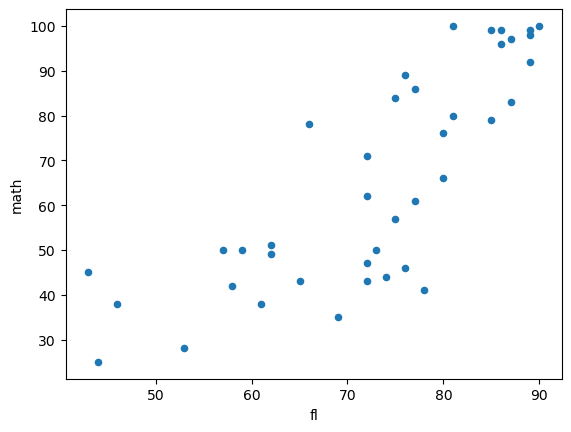

In [139]:
df.plot.scatter(x='fl', y='math');

There are more options to `pd.read_csv`, for example if `'AA'` is a value
indicating a non-existing value you can pass an option, called `na_values`.
Read more on the documentation for `read_csv`.

In [140]:
url = 'http://www.aero.iitb.ac.in/~prabhu/tmp/sslc1.csv.gz'
df = pd.read_csv(url, sep=';', na_values='AA')
df.head()

,region,roll_number,name,sl,fl,math,sci,ss,total,pass,withheld,extra
0,A,10001,DISMA J SURUTHY,53.0,36.0,28.0,16.0,44.0,177.0,NaN,NaN,NaN
1,A,10002,PARVIN M,58.0,37.0,42.0,35.0,40.0,212.0,P,NaN,NaN
2,A,10003,MANIKANDAN M,72.0,56.0,71.0,55.0,70.0,324.0,P,NaN,NaN
3,A,10004,PRABU R,87.0,64.0,83.0,58.0,65.0,357.0,P,NaN,NaN
4,A,10005,ARUNRAJ K,59.0,45.0,50.0,35.0,48.0,237.0,P,NaN,NaN


In [ ]:
df.dtypes

In [ ]:
df.describe()

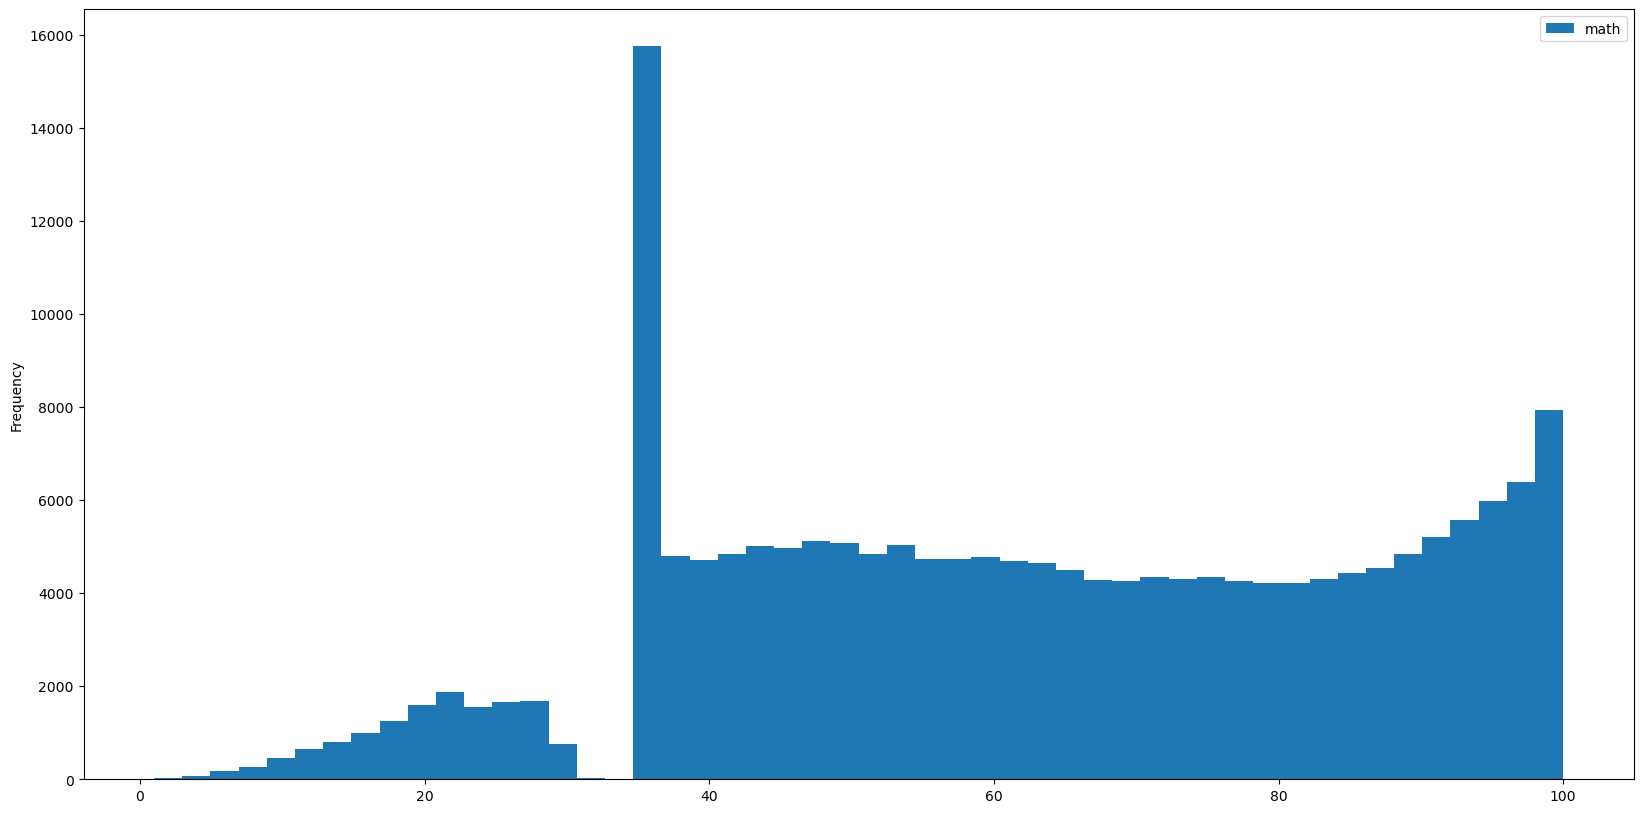

In [141]:
df.plot.hist(y='math', bins=50, figsize=(20, 10));

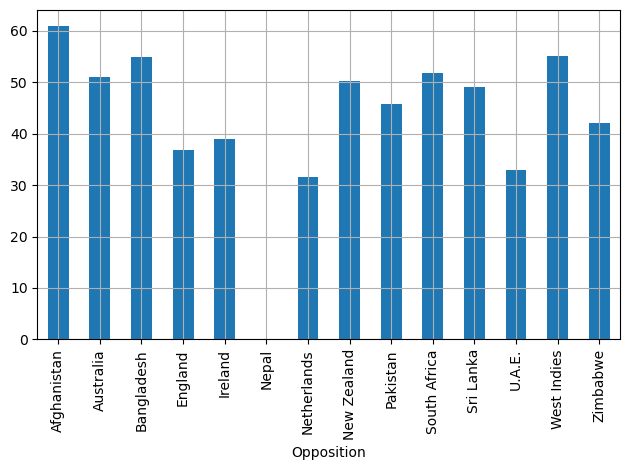

In [142]:
data.groupby('Opposition')['Runs'].mean().plot.bar()
plt.tight_layout()
plt.grid();

More information
==================

- Only scratched the surface.
- http://pandas.pydata.org

- Go through the chapter here: https://jakevdp.github.io/PythonDataScienceHandbook/03.00-introduction-to-pandas.html

- Go through the nice tutorials here:
   http://nbviewer.jupyter.org/github/jvns/pandas-cookbook/tree/v0.1/cookbook/